In [65]:
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import sys
sys.path.append("../..")
from src.utils import mark_repeated_columns

# Configs
import plotly.io as pio
pio.templates.default = "plotly_dark"

# Data

In [83]:
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa.xlsx'])
df = pd.read_excel(returns_path).loc[:, ["datetime", "value"]]
df.head()

,datetime,value
0,2024-12-02 10:00:00,125780.67
1,2024-12-02 10:05:00,125495.31
2,2024-12-02 10:10:00,125422.25
3,2024-12-02 10:15:00,125171.97
4,2024-12-02 10:20:00,125167.39


In [84]:
df2 = df[df.datetime.dt.minute % 5 == 0]

In [124]:
r_t = np.log(df2["value"]).diff().dropna()

rv = np.log(r_t**2)#.sum()      # realized variance
# log_vol = np.log(r_t)
# log_vol

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning:

divide by zero encountered in log



In [123]:
rv

1        5.158751e-06
2        3.391230e-07
3        3.989978e-06
4        1.338852e-09
5        1.328496e-07
             ...     
23254    2.299047e-08
23255    1.141964e-07
23256    5.066537e-08
23257    2.467471e-09
23258    5.574344e-08
Name: value, Length: 21832, dtype: float64

In [121]:
rv

1       -12.174816
2       -14.896903
3       -12.431725
4       -20.431453
5       -15.834048
           ...    
23254   -17.588186
23255   -15.985346
23256   -16.798023
23257   -19.820072
23258   -16.702506
Name: value, Length: 21832, dtype: float64

In [128]:
import statsmodels.api as sm
acf_values = sm.tsa.stattools.acf(rv, nlags=100)
n = len(rv)
conf_interval = 1.96 / np.sqrt(n)
# Lags with value > conf_interval (excluding lag 0)
significant_lags = np.where(np.abs(acf_values[1:]) > conf_interval)[0] + 1
print("Significant Lags:", significant_lags)

Significant Lags: []


/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:472: RuntimeWarning:

invalid value encountered in subtract

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/numpy/fft/_pocketfft.py:101: RuntimeWarning:

invalid value encountered in fft



In [70]:
# Data
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time").iloc[1:,:]
df = df.loc[:, ~mark_repeated_columns(df)[1]] # remove days with repeated values (due to anomalies like Ash Wednesday)

In [77]:
df

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16:40:00,-0.000169,0.000195,-0.000833,0.000137,0.000127,0.000062,0.000253,-0.003736,0.000405,0.000168,...,-0.000255,-0.000412,-0.000398,-0.000301,-0.000428,-0.000232,0.000473,-0.000521,0.000118,-0.000099
16:45:00,-0.000246,-0.000226,-0.000897,0.000536,0.001010,0.000047,-0.000063,0.002746,-0.000154,-0.000783,...,0.000344,0.000610,0.000224,-0.000353,0.000034,0.000054,-0.000519,0.000386,-0.000085,-0.000468
16:50:00,-0.000512,-0.000546,0.000553,0.000278,-0.000393,-0.000625,0.000141,-0.002952,0.002424,0.000244,...,0.000202,-0.000350,-0.000240,0.000239,-0.000314,-0.000175,0.000022,0.000298,0.000399,-0.000041


In [71]:
fig = px.line(
    df,
    color_discrete_sequence=['#80ed99'],  
    title="Returns by tick")

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.show()

In [72]:
df_realized_volatility = df**2

fig = px.line(
    df_realized_volatility,
    color_discrete_sequence=['#80ed99'],
    title="Realized volatility"
    )

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [73]:
vol = df_realized_volatility.sum()
log_vol = np.log(vol)
log_vol.name = "logVol"

In [74]:
fig = px.line(log_vol)
fig.show()

In [75]:
fig = px.scatter(y=log_vol, x=log_vol.shift(1))
fig.show()

In [ ]:
log_vol.corr(log_vol.shift(1))

np.float64(0.3093953764984038)

# Scores

In [36]:
scores_path = "../../data/processed/dfpc_scores.xlsx"
df_scores = pd.read_excel(scores_path).set_index("index")
# n1_scores = df_scores.iloc[:,1]
# n1_scores.index = df_scores["index"]

In [37]:
df_vol_scores = pd.concat([log_vol, df_scores], axis=1)

In [38]:
# df_vol_scores = pd.DataFrame(
#                         {
#                         "log_vol": log_vol.values,
#                         "scores":  n1_scores.values
#                         }, index=log_vol.index,
#                         )
df_vol_scores.corr(method="pearson")

,logVol,$η_1$,$η_2$,$η_3$,$η_4$,$η_5$
logVol,1.000000,0.900843,-0.077699,-0.217669,0.109995,0.234868
$η_1$,0.900843,1.000000,-0.108019,0.034234,0.022707,0.229480
$η_2$,-0.077699,-0.108019,1.000000,0.024804,-0.020438,-0.327926
$η_3$,-0.217669,0.034234,0.024804,1.000000,0.053647,0.053784
$η_4$,0.109995,0.022707,-0.020438,0.053647,1.000000,-0.163307
$η_5$,0.234868,0.229480,-0.327926,0.053784,-0.163307,1.000000


In [45]:
# df_vol_scores = pd.DataFrame(
#                         {
#                         "log_vol": log_vol.values,
#                         "scores":  n1_scores.values
#                         }, index=log_vol.index,
#                         )
df_vol_scores.corr(method="pearson")
fig = px.scatter_matrix(
    df_vol_scores,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [ ]:
fig = px.scatter(x=df_scores.iloc[:,2], y=log_vol)
fig.show()

In [49]:
fig = px.scatter(x=df_scores.iloc[:,1].shift(1), y=log_vol)
fig.show()

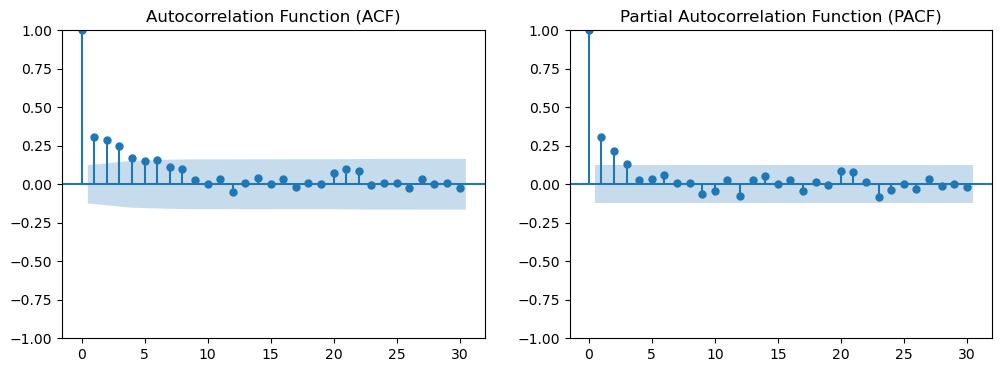

In [54]:
import matplotlib.pyplot as plt

# 2. Create subplots for displaying both graphs side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3. Plot the ACF
# The 'lags' parameter specifies how many lags to display.
plot_acf(log_vol, lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# 4. Plot the PACF
# The 'method' parameter can be set to 'ywm' or 'ols' for different estimation methods.
plot_pacf(log_vol, lags=30, ax=axes[1], method='ywm') 
axes[1].set_title('Partial Autocorrelation Function (PACF)')

# 5. Display the plots
plt.show()